EBU6505 Reasoning and Agents

Introduction to Post-Training for LLM Reasoning
===

**Dr Chao Shu (chao.shu@qmul.ac.uk)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
# import seaborn as sns
from scipy import stats

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Introduction
---

This lesson introduces post-training methods for improving the reasoning capabilities of Large Language Models (LLMs), with a particular focus on Group Relative Policy Optimization (GRPO) as a representative method presented in the [DeepSeekMath](https://arxiv.org/pdf/2402.03300) and DeepSeek R1 papers [v1, 2024]((https://arxiv.org/abs/2501.12948)) and [v2, 2026](https://arxiv.org/abs/2501.12948). Post-training is a crucial stage in modern LLM development because it allows a pretrained model to adapt its behaviour toward specific goals, such as producing more accurate answers, following structured output formats, and developing stronger multi-step reasoning abilities.

In this notebook, we focus on how reinforcement learning can be used after pretraining to incentivise better reasoning performance. We examine why GRPO is an important development in this area, especially because it avoids the need for a separate critic model and instead uses group-relative reward signals to guide learning. This makes GRPO both computationally efficient and well suited to reasoning-oriented tasks, where relative performance within a group of sampled responses can provide a strong learning signal.

To build intuition, this lesson combines theory and practice. We will break down the GRPO objective function, explain its core components such as advantage normalisation, importance sampling, clipping, and KL divergence regularisation, and walk through both theoretical and practical examples of GRPO loss computation. By the end of the notebook, you should have a clear understanding of how post-training with GRPO can be used to encourage stronger reasoning behaviour in LLMs.

In this lesson, we will:
1. Explain the theoretical foundations of GRPO.
2. Explore KL divergence and its role in stabilising policy updates.
3. Walk through GRPO objective and loss computation step by step.
4. Demonstrate how GRPO can incentivise reasoning capability in modern LLMs.

## GRPO Objective Function
---

According to the DeepSeekMath paper ([DeepSeek-AI, 2024](https://arxiv.org/pdf/2402.03300)), for each question $q$, GRPO samples a group of outputs $\{o_1, o_2, \ldots, o_G\}$ from the old policy $\pi_{\theta_{old}}$ and then optimises the policy model $\pi_{\theta}$ by maximising the following objective:

$$
\mathcal{J}_{GRPO}(\theta) = \mathbb{E}\left[q \sim P(Q), \{o_i\}_{i=1}^G \sim \pi_{\theta_{old}}(O|q)\right] \frac{1}{G} \sum_{i=1}^G \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \left\{ \min \left[ \frac{\pi_\theta(o_{i,t}|q, o_{i,<t})}{\pi_{\theta_{old}}(o_{i,t}|q, o_{i,<t})} \hat{A}_{i,t}, \text{clip} \left(\frac{\pi_\theta(o_{i,t}|q, o_{i,<t})}{\pi_{\theta_{old}}(o_{i,t}|q, o_{i,<t})}, 1-\epsilon, 1+\epsilon \right) \hat{A}_{i,t} \right] - \beta \mathbb{D}_{KL} \left[ \pi_\theta \| \pi_{ref} \right] \right\}
$$


where:
- $\varepsilon$ and $\beta$ are hyperparameters
- $\hat{A}_{i,t}$ is the advantage, computed using a group of rewards $\{r_1, r_2, \ldots, r_G\}$ corresponding to the outputs within each group
- $D_{KL}$ is the KL divergence between the current policy and a reference policy

The advantage $A_i$ is calculated as:

$$
A_i = \frac{r_i - \text{mean}(\{r_1, r_2, \ldots, r_G\})}{\text{std}(\{r_1, r_2, \ldots, r_G\})}
$$

And the KL divergence term is defined as:

$$
D_{KL}(\pi_{\theta}||\pi_{ref}) = \frac{\pi_{ref}(o_{i,t}|q, o_{i,<t})}{\pi_{\theta}(o_{i,t}|q, o_{i,<t})} - \log\frac{\pi_{ref}(o_{i,t}|q, o_{i,<t})}{\pi_{\theta}(o_{i,t}|q, o_{i,<t})} - 1
$$

According to DeepSeek R1 paper ([DeepSeek-AI, 2024](https://arxiv.org/abs/2501.12948)), the objective in the formular is written at the sequence level (see below). 

$$
J_{GRPO}(\theta) = \mathbb{E}_{[q \sim P(Q), \{o_i\}_{i=1}^G \sim \pi_{\theta_{old}}(O|q)]} \left[ \frac{1}{G} \sum_{i=1}^{G} \min\left(\frac{\pi_{\theta}(o_i|q)}{\pi_{\theta_{old}}(o_i|q)}A_i, \text{clip}\left(\frac{\pi_{\theta}(o_i|q)}{\pi_{\theta_{old}}(o_i|q)}, 1-\varepsilon, 1+\varepsilon\right)A_i\right) - \beta D_{KL}(\pi_{\theta}||\pi_{ref})\right]
$$

> 💡 Note:
> 
> In this lesson, we keep the objective function in the original form introduced first in the DeepSeekMath paper ([DeepSeek-AI, 2024](https://arxiv.org/pdf/2402.03300)), because it is more align with the open-source implementation of [`GRPOTraner`](https://huggingface.co/docs/trl/en/grpo_trainer) in the hugging face `TRL` (Transformers Reinforcement Learning) library. However, for Advantage, we use sequence Advantage denoted as $A_i$ in the DeepSeek R1 paper ([DeepSeek-AI, 2024](https://arxiv.org/abs/2501.12948)). 

### Key Components of GRPO


Let's break down the key components of the GRPO algorithm:

1. **Group Sampling**: Instead of sampling a single output, GRPO samples a group of outputs for each question.
2. **Advantage Calculation**: The advantage is calculated by normalising the reward of each output relative to the mean and standard deviation of the group rewards.
3. **Policy Ratio Clipping**: Similar to PPO (Proximal Policy Optimization), GRPO uses a clipped surrogate objective to prevent large policy updates.
4. **KL Divergence Regularization**: A KL divergence term is added to prevent the policy from deviating too far from a reference policy.

The combination of these components allows GRPO to efficiently optimise the policy model without requiring a separate value model.

![GRPO Diagram](https://huggingface.co/datasets/trl-lib/documentation-images/resolve/main/grpo_visual.png)

Image Source: Hugging Face TRL - [GRPO Trainer Documentation](https://huggingface.co/docs/trl/main/en/grpo_trainer)

### Advantage ($A_i$)

**Formula**:

$$
A_i = \frac{r_i - \text{mean}(\{r_1, r_2, \dots, r_G\})}{\text{std}(\{r_1, r_2, \dots, r_G\})}
$$

- The advantage tells us how much better or worse a specific response is compared to the average of the group. If an output is better than its peers, $A_i$ is positive. If it is worse, $A_i$ is negative.
- By multiplying our probabilities by $A_i$, we mathematically "push" the model to increase the probability of good tokens and decrease the probability of bad ones.
- For a given prompt, the model generates $G$ different responses. A reward model (or reward functions) assigns a raw score to each response. We then calculate the mean and standard deviation of those $G$ scores. Finally, we standardise each individual score by subtracting the group mean and dividing by the group standard deviation to get the Advantage.

### The Importance Sampling Ratio ($\rho_{i,t}$)

**Formula**:

$$
\rho_{i,t} = \frac{\pi_\theta(o_{i,t}|q, o_{i,<t})}{\pi_{\theta_{old}}(o_{i,t}|q, o_{i,<t})}
$$

- This is the ratio of the probability of generating a specific token under the current, active model ($\pi_\theta$) divided by the probability of generating that same token under the old model ($\pi_{\theta_{old}}$) that was originally used to roll out the response.
- Why we need it: In Reinforcement Learning, gathering data (generating text) is very slow. We want to reuse the same generated responses for multiple gradient updates. However, as the active model ($\pi_\theta$) learns and updates its weights, it is no longer the same model that generated the data. The Importance Sampling ratio mathematically corrects for this discrepancy, allowing us to safely learn from slightly "off-policy" data.
- During the **rollout phase**, we save the probability $\pi_{\theta_{old}}$ of each chosen token. During the **training** phase, the active model does a forward pass over that exact same text sequence and calculates its new probability $\pi_\theta$ for the tokens. We divide the new probability by the old probability. A ratio $>1.0$ means the token is more likely now; $<1.0$ means it is less likely.

### The Clipping Component

**Formula**:

$$
\min \left[ \rho_{i,t} A_i, \text{clip} (\rho_{i,t}, 1-\epsilon, 1+\epsilon) A_i \right]
$$

- The clip function restricts the ratio $\rho_{i,t}$ so it cannot exceed the range $[1-\epsilon, 1+\epsilon]$ (where $\epsilon$ is usually $0.2$). The `min` function then selects the lowest value between the unclipped and clipped advantage.
- Neural networks are prone to catastrophic forgetting if their weights change too drastically in a single step. If the active model finds a highly rewarding action, it might try to update its probabilities massively, destroying the rest of the policy. The clipping mechanism acts as a pessimistic bound, ensuring the new policy stays within a "trust region" close to the old policy. It prevents greedy, unstable updates.
- We first calculate the unclipped objective ($\rho \times A$) and the clipped objective ($\text{clip}(\rho) \times A$). By applying the min function, the algorithm refuses to reward the model for aggressively changing its probability on a good action (if the ratio exceeds the upper bound). However, if the model drastically drops the probability of a good action, the min function allows the penalty to pass through unbounded.

### The KL Divergence Penalty ($\mathbb{D}_{KL}$)

Kullback-Leibler (KL) divergence is a measure of how one probability distribution differs from a reference probability distribution. In the context of reinforcement learning, KL divergence is often used as a regularisation term to prevent the policy from changing too drastically between updates.

The standard formula for KL divergence between two discrete probability distributions $P$ and $Q$ is:

$$
D_{KL}(P||Q) = \sum_{x} P(x) \log\frac{P(x)}{Q(x)}
$$

For continuous distributions, the sum is replaced by an integral.

In the GRPO algorithm, it estimates the KL divergence with the following unbiased estimator [(Schulman, 2020)](http://joschu.net/blog/kl-approx.html):

$$
D_{KL}(\pi_{\theta}||\pi_{ref}) = \frac{\pi_{ref}(o_{i,t}|q, o_{i,<t})}{\pi_{\theta}(o_{i,t}|q, o_{i,<t})} - \log\frac{\pi_{ref}(o_{i,t}|q, o_{i,<t})}{\pi_{\theta}(o_{i,t}|q, o_{i,<t})} - 1
$$

This form is derived from the general KL divergence formula and is adapted for the specific needs of the GRPO algorithm.

> 💡 Note:
> 
> It is important to note that KL Divergence is asymmetric (the distance from $P$ to $Q$ is not the same as $Q$ to $P$), i.e., $D_{KL}(P||Q) \neq D_{KL}(Q||P)$.

#### KL Divergence for Continuous Distributions

Let's create an interactive visualisation to explore how KL divergence changes as we vary the parameters of two normal distributions.

In [2]:
def gaussian_kl_divergence(mu1, sigma1, mu2, sigma2):
    """Calculate KL divergence between two Gaussian distributions."""
    return (np.log(sigma2/sigma1) + 
            (sigma1**2 + (mu1 - mu2)**2) / (2 * sigma2**2) - 0.5)

def plot_gaussian_distributions(mu1, sigma1, mu2, sigma2):
    """Plot two Gaussian distributions and calculate their KL divergence."""
    x = np.linspace(-10, 10, 1000)
    p = stats.norm.pdf(x, mu1, sigma1)
    q = stats.norm.pdf(x, mu2, sigma2)
    
    kl = gaussian_kl_divergence(mu1, sigma1, mu2, sigma2)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, p, label=f'P ~ N({mu1}, {sigma1}²)')
    plt.plot(x, q, label=f'Q ~ N({mu2}, {sigma2}²)')
    plt.fill_between(x, p, q, where=(p > q), alpha=0.3, color='red', 
                     label=f'KL(P||Q) = {kl:.4f}')
    plt.fill_between(x, p, q, where=(p <= q), alpha=0.3, color='blue')
    plt.title('KL Divergence Between Two Gaussian Distributions')
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return kl

In [3]:
from ipywidgets import interact, FloatSlider

@interact(
    mu1=FloatSlider(min=-5, max=5, step=0.1, value=0, description='μ₁:'),
    sigma1=FloatSlider(min=0.1, max=3, step=0.1, value=1, description='σ₁:'),
    mu2=FloatSlider(min=-5, max=5, step=0.1, value=2, description='μ₂:'),
    sigma2=FloatSlider(min=0.1, max=3, step=0.1, value=1.5, description='σ₂:')
)
def interactive_kl_divergence(mu1, sigma1, mu2, sigma2):
    kl = plot_gaussian_distributions(mu1, sigma1, mu2, sigma2)
    kl_reverse = gaussian_kl_divergence(mu2, sigma2, mu1, sigma1)
    print(f"KL(P||Q) = {kl:.4f}")
    print(f"KL(Q||P) = {kl_reverse:.4f}")
    print(f"Difference = {abs(kl - kl_reverse):.4f}")

interactive(children=(FloatSlider(value=0.0, description='μ₁:', max=5.0, min=-5.0), FloatSlider(value=1.0, des…

#### KL Divergence for Categorical Distributions

In reinforcement learning with discrete action spaces, we often work with categorical distributions. Let's visualise KL divergence between categorical distributions.

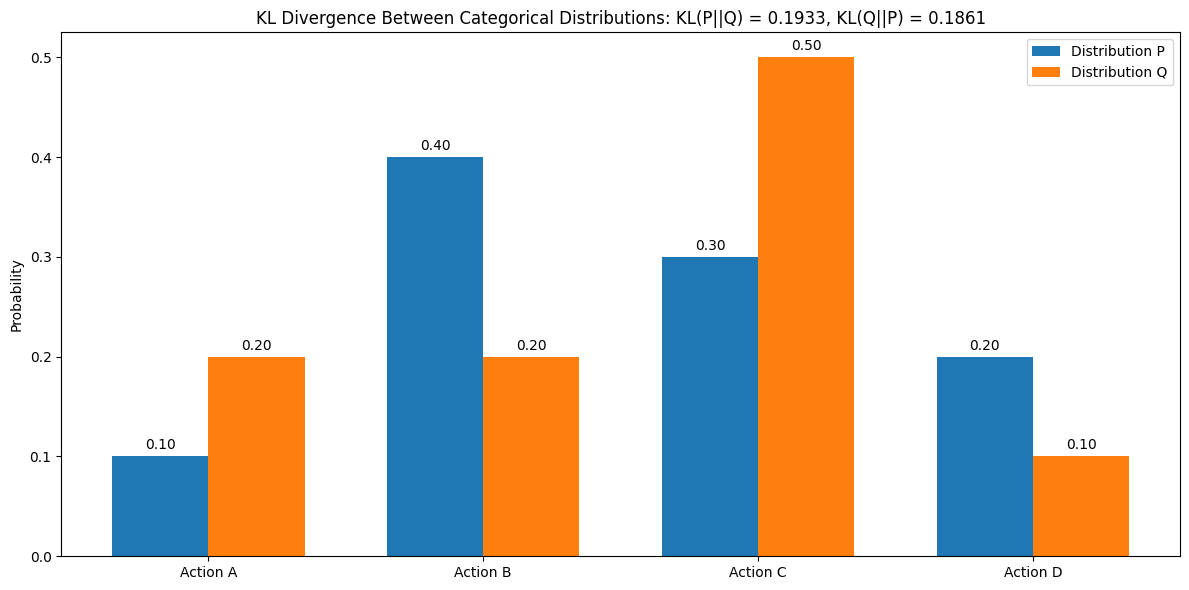

KL(P||Q) = 0.1933
KL(Q||P) = 0.1861
Difference = 0.0072


In [4]:
def categorical_kl_divergence(p, q):
    """Calculate KL divergence between two categorical distributions."""
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = np.array(p) + epsilon
    q = np.array(q) + epsilon
    
    # Normalize to ensure they are valid probability distributions
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    return np.sum(p * np.log(p / q))

def plot_categorical_distributions(p, q, labels=None):
    """Plot two categorical distributions and calculate their KL divergence."""
    if labels is None:
        labels = [f'Category {i+1}' for i in range(len(p))]
    
    kl = categorical_kl_divergence(p, q)
    kl_reverse = categorical_kl_divergence(q, p)
    
    x = np.arange(len(p))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, p, width, label='Distribution P')
    rects2 = ax.bar(x + width/2, q, width, label='Distribution Q')
    
    ax.set_ylabel('Probability')
    ax.set_title(f'KL Divergence Between Categorical Distributions: KL(P||Q) = {kl:.4f}, KL(Q||P) = {kl_reverse:.4f}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    # Add values on top of bars
    def autolabel(rects, values):
        for rect, value in zip(rects, values):
            height = rect.get_height()
            ax.annotate(f'{value:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    autolabel(rects1, p)
    autolabel(rects2, q)
    
    fig.tight_layout()
    plt.show()
    
    return kl, kl_reverse

# Example: Visualize KL divergence between two categorical distributions
p = [0.1, 0.4, 0.3, 0.2]
q = [0.2, 0.2, 0.5, 0.1]
labels = ['Action A', 'Action B', 'Action C', 'Action D']

kl, kl_reverse = plot_categorical_distributions(p, q, labels)
print(f"KL(P||Q) = {kl:.4f}")
print(f"KL(Q||P) = {kl_reverse:.4f}")
print(f"Difference = {abs(kl - kl_reverse):.4f}")

#### KL Divergence in the GRPO Context

Now, let's implement and visualise the unbiased estimator used in GRPO.

Standard KL(P||Q) = 0.1933
GRPO KL(P||Q) = 0.2367


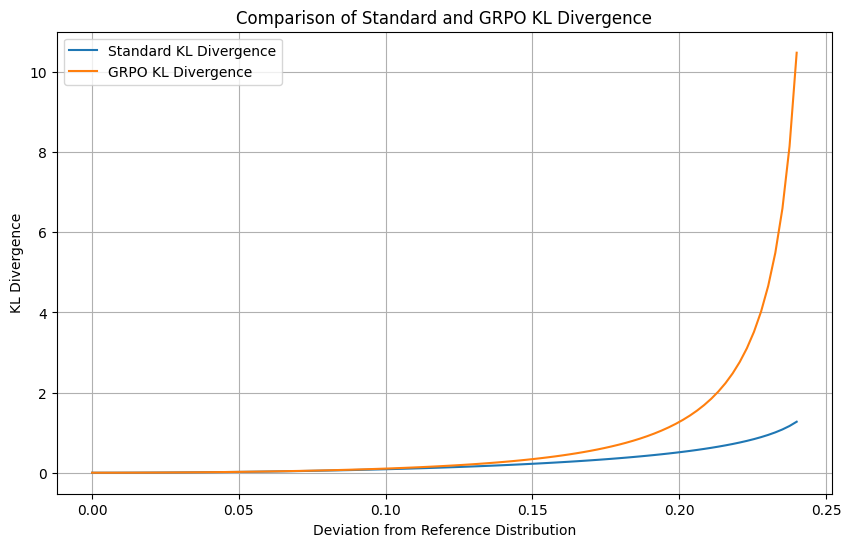

In [5]:
def grpo_kl_divergence(pi_ref, pi_theta):
    """Calculate KL divergence as defined in the GRPO paper."""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-10
    pi_ref = np.array(pi_ref) + epsilon
    pi_theta = np.array(pi_theta) + epsilon
    
    # Normalize to ensure they are valid probability distributions
    pi_ref = pi_ref / np.sum(pi_ref)
    pi_theta = pi_theta / np.sum(pi_theta)
    
    # Calculate the ratio
    ratio = pi_ref / pi_theta
    
    # Calculate KL divergence according to the GRPO formula
    kl = ratio - np.log(ratio) - 1
    
    return np.sum(pi_ref * kl)

# Example: Compare standard KL divergence with GRPO KL divergence
pi_ref = [0.1, 0.4, 0.3, 0.2]
pi_theta = [0.2, 0.2, 0.5, 0.1]

standard_kl = categorical_kl_divergence(pi_ref, pi_theta)
grpo_kl = grpo_kl_divergence(pi_ref, pi_theta)

print(f"Standard KL(P||Q) = {standard_kl:.4f}")
print(f"GRPO KL(P||Q) = {grpo_kl:.4f}")

# Visualize how GRPO KL divergence changes as pi_theta deviates from pi_ref
def visualize_grpo_kl_sensitivity():
    pi_ref = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform reference distribution
    
    # Create a range of deviations
    deviations = np.linspace(0, 0.24, 100)  # Max deviation is 0.24 to keep probabilities positive
    standard_kls = []
    grpo_kls = []
    
    for dev in deviations:
        # Create a deviated distribution
        pi_theta = np.array([0.25 - dev, 0.25 - dev, 0.25 + dev, 0.25 + dev])
        
        # Calculate KL divergences
        standard_kls.append(categorical_kl_divergence(pi_ref, pi_theta))
        grpo_kls.append(grpo_kl_divergence(pi_ref, pi_theta))
    
    plt.figure(figsize=(10, 6))
    plt.plot(deviations, standard_kls, label='Standard KL Divergence')
    plt.plot(deviations, grpo_kls, label='GRPO KL Divergence')
    plt.xlabel('Deviation from Reference Distribution')
    plt.ylabel('KL Divergence')
    plt.title('Comparison of Standard and GRPO KL Divergence')
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_grpo_kl_sensitivity()

- In GRPO, we use KL divergence to measure the difference between our active model ($\pi_\theta$) and a frozen Reference Model ($\pi_{ref}$, usually the original model before RL fine-tuning started). $\beta$ controls the strength of this penalty.
- This penalty prevents Reward Hacking. If left unchecked, the model might learn to exploit the reward function by outputting nonsensical text that technically triggers high rewards, or it might completely lose its general conversational abilities to excel at one narrow task. The KL penalty pulls the model back, ensuring it doesn't deviate too far from a natural language baseline. (Note: DeepSeekMath uses a specific computationally efficient estimator for this KL term).
- For every token generated, we compute the probability from the active model and the frozen reference model. Using the unbiased estimator formula, we calculate a non-negative penalty value. We multiply this penalty by a coefficient ($\beta$) and subtract it from the surrogate objective, actively reducing the loss score if the model deviate too far from the reference.

### From Objective to Loss Function

To maximize the GRPO objective in a Deep Learning framework (e.g., PyTorch), we simply take the negative of it to create our Loss function:

$$
\mathcal{L}_{GRPO} = - \mathcal{J}_{GRPO}
$$

By minimising the negative objective, the Deep Learning framework's optimiser handles the gradient descent perfectly, pushing the model's weights in the direction of higher rewards.

## GRPO Algorithm Procedure
---

![GRPO Algorithm in DeepSeek Math paper](imgs/L05_DS_Math_GRPO_Algo.png)

Image Source: Hugging Face TRL - [DeepSeekMath Paper](https://arxiv.org/abs/2402.03300)

> 💬 **Discussion:** 
> 
> How does the DeepSeek-R1-Zero training process fit into this algorithm.

*Your notes here*

## GRPO Objective/Loss Computation Tutorial
---

This tutorial breaks down the **core** mathematical components of the GRPO algorithm and walks you through the key steps using a theoretical example and a practical example with real output from Qwen2.5 1.5B.

### Theoretical Example

#### Phase 1: The Rollout Phase (Generation & Evaluation)

Instead of relying on a separate Value Model to estimate a reward baseline, GRPO generates a group of $G$ responses for the same prompt and normalises the rewards within that group to calculate the Group Advantage ($A_i$).

**Example 1:**

The old policy model ($\pi_{\theta_{old}}$) is given the prompt "What is the chemical symbol for water?" and generates $G=4$ responses during rollout. The reward model evaluates them (checking for factual correctness and formatting) and assigns the following scores:

- Response 1: "It is H2O" ($r_1 = 9$)
- Response 2: "The answer is H2O" ($r_2 = 9$)
- Response 3: "It is CO2" ($r_3 = 1$)
- Response 4: "Water is O2" ($r_4 = 1$)

Calculate the Advantage score ($A_1$) for Response 1, and ($A_3$) for Response 3.

**Solution:**

Mean: $(9 + 9 + 1 + 1) / 4 = 20 / 4 = 5$

Standard Deviation: Std = $\sqrt{\frac{(9-5)^2 + (9-5)^2 + (1-5)^2 + (1-5)^2}{4}} = \sqrt{\frac{16 + 16 + 16 + 16}{4}} = \sqrt{\frac{64}{4}} = 4$

Advantage $A_1$: $(9 - 5) / 4 = +1.0$

Advantage $A_3$: $(1 - 5) / 4 = -1.0$

#### Phase 2: The Training Phase (Policy Optimisation)

Once the rollout is complete and advantages are calculated, we enter the inner GRPO training loop. Here, the active policy ($\pi_\theta$) is updated over several iterations to maximise the objective function.

##### Step 2.1: Inner-Epoch Initialisation

**Example 2:**

After GRPO sampled a batch of responses and is at the very first forward pass of a new GRPO inner-iteration block. At this exact moment, what is the value of the Importance Sampling Ratio $\rho_{i,t} = \frac{\pi_\theta(t)}{\pi_{\theta_{old}}(t)}$ for every token? Why?

Solution:

At the start of a new generation/iteration block, the old policy was synchronized with the active policy ($\pi_{\theta_{old}} \leftarrow \pi_\theta$). Therefore, for the very first forward pass, the active model hasn't updated its weights yet, so $\pi_\theta(t) = \pi_{\theta_{old}}(t)$.
The ratio $\rho_{i,t} = \frac{\pi_\theta(t)}{\pi_{\theta_{old}}(t)}$ will be exactly $1.0$ for all tokens.

##### Step 2.2: Token-Level Surrogate Objective & Clipping

As training progresses and $\pi_\theta$ updates, its probabilities diverge from $\pi_{\theta_{old}}$. To prevent the policy from changing too drastically in a single update, GRPO calculates the surrogate objective token-by-token and clips the Importance Sampling ratio ($\rho_{i,t}$).

**Example 3:**

Assume the clipping hyperparameter $\epsilon = 0.2$ (so the clip range is $[0.8, 1.2]$). We will evaluate Response 1 from Example 1, which has an Advantage of $A_1 = +1.0$. The response is "It is H2O", broken into three tokens: ["It", " is", " H2O"].

**Rollout Probabilities:** During the previous rollout phase, the old policy ($\pi_{\theta_{old}}$) recorded the following probabilities for generating these tokens:

- Token 1 ("It"): $\pi_{\theta_{old}}(t_1) = 0.80$
- Token 2 (" is"): $\pi_{\theta_{old}}(t_2) = 0.50$
- Token 3 (" H2O"): $\pi_{\theta_{old}}(t_3) = 0.50$

**Current Training Step:** The active model ($\pi_\theta$) performs a forward pass. Because it has updated slightly in previous micro-batches, it yields different probabilities:

- Token 1 ("It"): $\pi_\theta(t_1) = 0.88$
- Token 2 (" is"): $\pi_\theta(t_2) = 0.70$
- Token 3 (" H2O"): $\pi_\theta(t_3) = 0.30$

Calculate the surrogate objective for each token (excluding KL).

**Solution:**

- Token 1 ("It"):
  - $\rho_{1,1} = 0.88 / 0.80 = 1.10$
  - Unclipped: $1.10 \times 1.0 = 1.10$
  - Clipped term: $\text{clip}(1.10, 0.8, 1.2) \times 1.0 = 1.10$
  - Objective: $\min(1.10, 1.10) = 1.10$

- Token 2 (" is"):
  - $\rho_{1,2} = 0.70 / 0.50 = 1.40$
  - Unclipped: $1.40 \times 1.0 = 1.40$
  - Clipped term: $\text{clip}(1.40, 0.8, 1.2) \times 1.0 = 1.20$
  - Objective: $\min(1.40, 1.20) = 1.20$

- Token 3 (" H2O"):
  - $\rho_{1,3} = 0.30 / 0.50 = 0.60$
  - Unclipped: $0.60 \times 1.0 = 0.60$
  - Clipped term: $\text{clip}(0.60, 0.8, 1.2) \times 1.0 = 0.80$
  - Objective: $\min(0.60, 0.80) = 0.60$

##### Step 2.3: The KL Divergence Penalty

In addition to the surrogate objective, we penalize the active model ($\pi_\theta$) token-by-token if it deviates too far from the original frozen Reference Model ($\pi_{ref}$). This prevents "reward hacking" (where the model outputs gibberish that technically satisfies the reward function). The final token objective combines the surrogate objective and this KL penalty, which is then averaged across the sequence to get the final sequence objective.

**Formula (GRPO Estimator):**

$$
\mathbb{D}_{\mathbb{KL}}(t) = \frac{\pi_{ref}(t)}{\pi_\theta(t)} - \ln\left(\frac{\pi_{ref}(t)}{\pi_\theta(t)}\right) - 1
$$

**Example 4:**

Let's continue with Response 1 from Example 3. Assume the KL penalty coefficient is $\beta = 0.1$. The frozen reference model ($\pi_{ref}$) probabilities for our three tokens are:

- Token 1 ("It"): $\pi_{ref}(t_1) = 0.88$
- Token 2 (" is"): $\pi_{ref}(t_2) = 0.70$
- Token 3 (" H2O"): $\pi_{ref}(t_3) = 0.90$

Using the active model probabilities ($\pi_\theta$) from Example 3, calculate the token-level KL penalty for each token, and the final combined sequence objective.

**Solution:**

1. Calculate Token-Level KL Penalty:
  - Token 1 ("It"):
    - Ratio $\frac{\pi_{ref}}{\pi_\theta} = 0.88 / 0.88 = 1.0$
    - $\mathbb{D}_{\mathbb{KL}} = 1.0 - \ln(1.0) - 1 = 1.0 - 0 - 1 = 0$

  - Token 2 (" is"):
    - Ratio $\frac{\pi_{ref}}{\pi_\theta} = 0.70 / 0.70 = 1.0$
    - $\mathbb{D}_{\mathbb{KL}} = 1.0 - \ln(1.0) - 1 = 0$
  
  - Token 3 (" H2O"):
    - Ratio $\frac{\pi_{ref}}{\pi_\theta} = 0.90 / 0.30 = 3.0$
    - $\mathbb{D}_{\mathbb{KL}} = 3.0 - \ln(3.0) - 1 \approx 3.0 - 1.099 - 1 = 0.901$

2. Calculate Final Token Objectives (Surrogate - $\beta \times \mathbb{D}_{\mathbb{KL}}$):
  - Token 1 Final: $1.10 - (0.1 \times 0) = 1.10$
  - Token 2 Final: $1.20 - (0.1 \times 0) = 1.20$
  - Token 3 Final: $0.60 - (0.1 \times 0.901) = 0.60 - 0.0901 = 0.5099$

3. Total Final Sequence Objective:
   - Average: $(1.10 + 1.20 + 0.5099) / 3 = 2.8099 / 3 \approx 0.937$

### Practical Example

In this section, the outputs of GRPO loss computation based on Qwen2.5 1.5B model are used to demonstrate the simplified core steps of GRPO loss computation for educational purpose. The original Qwen2.5 1.5B model is used as the old policy model ($\pi_{\theta_{old}}$), a Qwen2.5 1.5B model with a tiny LoRA adapter is used to mimic an active policy model ($\pi_{\theta}$) that is different from the $\pi_{\theta_{old}}$.

The prompt used in this example is: "What is 15 + 27? Give a very short rationale, then finish with 'FINAL: \<integer\>'."

Parameters:
- lora_rank=4
- lora_alpha=8
- temperature=1.0
- num_generation=4
- $\beta=0$: no KL Divergence to simpifly the process and save RAM.

> 🤖 Learning by DOING:
> 
> You are encouraged to work with your AI assistant to implement a simplified GRPO loss computation to gain a deep understanding of GRPO loss computation.

#### Phase 1: The Rollout Phase (Generation & Evaluation)

```text
Rollout batch size: 4 completion(s)

  Sample 1 (Math problem) | completion tokens=15
    Full completion: 'Rationale: Addition of two positive integers.\nFINAL: 42.'
  Sample 2 (Math problem) | completion tokens=23
    Full completion: 'Rationale: Adding 15 and 27 involves combining these two numbers.\nFINAL: 42.'
  Sample 3 (Math problem) | completion tokens=24
    Full completion: '15 + 27 = 42. Rationale: Adding the numbers together. Final: 42'
  Sample 4 (Math problem) | completion tokens=16
    Full completion: '15 + 27 = 42\n\nFINAL: 42'
  Diversity (Math problem): 4/4 unique completion(s)
```

```text
Per-sample reward breakdown:
  Sample 01 (Math problem) target='42' reward=0.8 completion_tokens=15
    Full completion: 'Rationale: Addition of two positive integers.\nFINAL: 42.'
  Sample 02 (Math problem) target='42' reward=0.8 completion_tokens=23
    Full completion: 'Rationale: Adding 15 and 27 involves combining these two numbers.\nFINAL: 42.'
  Sample 03 (Math problem) target='42' reward=0.5 completion_tokens=24
    Full completion: '15 + 27 = 42. Rationale: Adding the numbers together. Final: 42'
  Sample 04 (Math problem) target='42' reward=1.0 completion_tokens=16
    Full completion: '15 + 27 = 42\n\nFINAL: 42'
```

```text
Group 1: mean=0.7750, std=0.2062
    Sample 1: reward=0.8 -> advantage=0.1212
    Sample 2: reward=0.8 -> advantage=0.1212
    Sample 3: reward=0.5 -> advantage=-1.3333
    Sample 4: reward=1.0 -> advantage=1.0909

FINAL GRPO LOSS: 0.200285
```

#### Phase 2: The Training Phase (Policy Optimisation)

Let's focus on **the last 5 tokens** in the **Sample 01** in the rollout group.

```text
top-5 comparison (pi_old vs pi_theta):
      token #11 chosen=':'
      rank | pi_old token         logp     prob || pi_theta token       logp     prob
      -------------------------------------------------------------------------------
      1    | *':'              -0.0000   1.0000 || *':'              -0.1220   0.8851
      2    |  ':\\n'          -12.6094   0.0000 ||  ','              -3.3398   0.0354
      3    |  ' answer'       -13.6875   0.0000 ||  "'"              -4.7305   0.0088
      4    |  ':<'            -14.6875   0.0000 ||  '.'              -4.9492   0.0071
      5    |  ':\\n\\n'       -15.3750   0.0000 ||  '"'              -5.6992   0.0033

      token #12 chosen=' '
      rank | pi_old token         logp     prob || pi_theta token       logp     prob
      -------------------------------------------------------------------------------
      1    | *' '              -0.0005   0.9995 || *' '              -0.5664   0.5676
      2    |  ' <'             -7.5312   0.0005 ||  ' The'           -2.8242   0.0594
      3    |  ' **'           -12.2188   0.0000 ||  ' ['             -4.0508   0.0174
      4    |  ' ['            -13.1094   0.0000 ||  ' <'             -4.2070   0.0149
      5    |  '3'             -14.8281   0.0000 ||  ' -'             -4.5117   0.0110

      token #13 chosen='4'
      rank | pi_old token         logp     prob || pi_theta token       logp     prob
      -------------------------------------------------------------------------------
      1    | *'4'              -0.0001   0.9999 ||  '1'              -1.2031   0.3003
      2    |  '1'              -9.0938   0.0001 || *'4'              -1.8984   0.1498
      3    |  '3'             -12.6562   0.0000 ||  '2'              -2.2031   0.1105
      4    |  '2'             -12.6719   0.0000 ||  '5'              -3.0391   0.0479
      5    |  ' '             -13.3906   0.0000 ||  '8'              -3.2656   0.0382

      token #14 chosen='2'
      rank | pi_old token         logp     prob || pi_theta token       logp     prob
      -------------------------------------------------------------------------------
      1    | *'2'              -0.0000   1.0000 ||  ' +'             -1.3184   0.2676
      2    |  '3'             -14.8594   0.0000 ||  ' >'             -2.0449   0.1294
      3    |  '1'             -15.6562   0.0000 ||  '+'              -2.6465   0.0709
      4    |  '5'             -17.2344   0.0000 ||  ' <='            -3.1074   0.0447
      5    |  '4'             -17.7188   0.0000 ||  ' <'             -3.1855   0.0414

      token #15 chosen='.'
      rank | pi_old token         logp     prob || pi_theta token       logp     prob
      -------------------------------------------------------------------------------
      1    | *'.'              -0.5107   0.6001 ||  ' +'             -0.9092   0.4029
      2    |  '<|im_end|>'     -0.9170   0.3997 ||  ' -'             -2.5352   0.0792
      3    |  ' '             -10.2344   0.0000 ||  '+'              -2.5430   0.0786
      4    |  '<|im_start|>'  -10.3672   0.0000 ||  '6'              -3.4023   0.0333
      5    |  '.\\n\\n'       -10.3828   0.0000 ||  ' >'             -3.4883   0.0306
```

```text
Prompt group 1 (Math problem), sample 1, A_i=0.1212:
    tok#  token         log pi_old  log pi_theta    rho_raw    clip(rho)    rho*A      clip*A        kept
    --------------------------------------------------------------------------------------------------------------------
    11    ':'              -0.0000       -0.1220     0.8851     0.8851      0.1073      0.1073      0.1073
    12    ' '              -0.0005       -0.5664     0.5679     0.8000      0.0688      0.0970      0.0688
    13    '4'              -0.0001       -1.8984     0.1498     0.8000      0.0182      0.0970      0.0182
    14    '2'              -0.0000       -5.7031     0.0033     0.8000      0.0004      0.0970      0.0004
    15    '.'              -0.5107       -5.9102     0.0045     0.8000      0.0005      0.0970      0.0005
```

```text
Sample 1 objective:
  Sample 1 uses A_i=0.1212, |o_i|=15
  Token objectives obj_t (all completion tokens):
    [6.2e-05, 0.053568, 0.102842, 1.4e-05, 0.008075, 0.01019, 0.00133, 0.145451, 0.001496, 2e-06, 0.107288, 0.068831, 0.01816, 0.000404, 0.000548]
  Sequence objective J_1       = 0.518263 / 15 = 0.034551
  Sequence loss L_1            = -J_1 = -0.034551
```

```text
Per-sequence loss:
  Sample 1: -0.034551
  Sample 2: -0.035906
  Sample 3: 1.124058
  Sample 4: -0.252462

FINAL GRPO LOSS: 0.200285
```

> 💬 **Discussion:** 
> 
> By now, you should have a good understanding of how the GRPO Objective/Loss function works in the original DeepSeek Math paper. 
> Please read [GRPO Trainer Documentation](https://huggingface.co/docs/trl/main/en/grpo_trainer) to find out what formulas are used to compute GRPO Objective/Loss in implementation in the widely-used `GRPOTrainer`.

*Your notes here*

## Incentivise Reasoning Capability in LLMs using GRPO
---

![DeepSeek R1 Zero Training Performance](imgs/L05_DS_R1Zero_TrainingPerformance.png)

According to [DeepSeek-AI, 2026](https://arxiv.org/abs/2501.12948)
- The average **pass@1** score on AIME 2024 shows a significant increase, jumping from an initial 15.6% to 77.9%
- In addition, by leveraging the **self-consistency decoding** [Wang et al. (2022)](https://arxiv.org/abs/2203.11171), the model’s performance can be further improved, achieving an accuracy of 86.7%.
- **These results underscore the effectiveness of RL in enhancing the reasoning capabilities of large language models.**
- **Inference Time Scaling**: DeepSeek-R1-Zero exhibits a steady increase in thinking time throughout training, driven solely by intrinsic adaptation rather than external modifications. Leveraging **long CoT**, the model progressively refines its reasoning, generating hundreds to thousands of tokens to explore and improve its problem-solving strategies.

### Benefits of GRPO

Let's analyze the comparison between GRPO and simple policy gradient:

1. **Computational Efficiency**: By removing the need for a separate Value Model (which is typically the same size as the Policy Model), GRPO reduces the memory footprint and compute requirements.
2. **Stability**: In reasoning tasks, absolute reward values can be noisy or hard to calibrate. GRPO's group-relative approach acts as an "automatic curve," where the model is only rewarded for being better than its current average performance. This makes the training signal more stable and less dependent on the absolute scale of the reward model.

2. **Incentivizing Diverse Exploration**: Because rewards are calculated relative to a group, the model is penalised if it produces repetitive, mediocre responses that fall below the group mean. This encourages the model to explore different reasoning paths within its Chain of Thought (CoT) to find higher-reward "outliers" (i.e., correct and well-formatted answers).

In DeepSeek R1-Zero, GRPO was used to demonstrate that reasoning (Chain of Thought) can emerge purely through RL without any Supervised Fine-Tuning (SFT). The relative advantage signal was sufficient to "discover" that longer reasoning leads to higher accuracy rewards, effectively bootstrapping the model's intelligence.

## Conclusion
---

In this notebook, we explored Group Relative Policy Optimization (GRPO) as a post-training method for improving LLM reasoning. We examined its mathematical foundations, the role of KL regularisation and clipped policy updates, and how GRPO can encourage stronger reasoning behaviour through reward-driven reinforcement learning.

**Key Takeaways**
1. **GRPO Foundations**: GRPO improves on traditional RL fine-tuning by removing the need for a separate critic model and instead using group-relative rewards to estimate advantage.
2. **Core Objective Components**: The GRPO objective combines group-based advantage estimation, importance sampling, clipping, and KL divergence regularisation to make policy updates both effective and stable.
3. **KL Divergence Intuition**: KL divergence helps keep the updated policy close to a reference model, reducing reward hacking and preserving useful language behaviour during optimisation.
4. **Step-by-Step Loss Computation**: Working through theoretical and practical examples makes it easier to understand how rollout rewards, advantages, token-level objectives, and final GRPO loss are computed.
5. **Reasoning Emergence Through RL**: GRPO shows how reinforcement learning can directly incentivise better reasoning, longer chain-of-thought behaviour, and stronger performance without relying entirely on supervised fine-tuning.
6. **Practical Benefits**: GRPO offers computational efficiency, more stable learning signals, and better exploration of alternative reasoning paths, making it a powerful method for post-training reasoning-capable LLMs.
7. **From Theory to Practice**: The [`GRPOTrainer`](https://huggingface.co/docs/trl/main/en/grpo_trainer) provide a comprehensive implementation of GRPO algorithm, getting familiar and understanding the key implementation parameters are essential for you to bridge the gap between the theory and real-world projects.

GRPO represents an important development in post-training for LLM reasoning. By combining efficient optimisation with group-relative learning signals, it provides a practical and effective framework for encouraging stronger reasoning performance in modern language models.